# 突触路由架构 (SRA) 快速入门

该笔记本是一个演示，旨在轻松体验 SRA 的基本机制及其主要功能“路由”行为。
您只需在 Google Colab 等环境中按从上至下的顺序运行单元即可观察 SRA 的行为。

## 1. 环境设置
如果您在 Google Colab 上运行此程序，请执行以下单元来克隆存储库并安装所需的库。

In [1]:
# Run only in Colab environment (skip if local)
import sys
if 'google.colab' in sys.modules:
    !git clone https://github.com/JunSuzukiJapan/SynapticRouter.git
    %cd SynapticRouter
    !pip install torch matplotlib seaborn

# Add path
sys.path.append('.')
sys.path.append('./src')
if 'google.colab' not in sys.modules:
    sys.path.append('..')
    sys.path.append('../src')


## 2.导入库并准备模型
初始化 SRA MoE（专家混合）模型。

In [2]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from src.sra_gpu_models import MoESRAModel
class MoESRAConfig:
    def __init__(self, **kwargs):
        for k, v in kwargs.items():
            setattr(self, k, v)

# Use GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Initialize model with a small configuration
config = MoESRAConfig(
    vocab_size=100,
    d_model=64,
    n_layers=2,
    n_heads=4,
    num_synapses=4,  # 4 experts (synapses)
    k=2,       # Select 2 synapses per token
    max_seq_len=64
)
model = MoESRAModel(config.vocab_size, config.d_model, config.n_layers, config.num_synapses, config.k, syn_hidden=128).to(device)
print("Model initialized!")

Using device: cpu
Model initialized!


## 3. 使用虚拟数据进行前向传递和路由检查
输入任意数据并检查模型如何路由到每个突触（专家）。

In [3]:
# Dummy data with batch size 2 and sequence length 10
x = torch.randint(0, config.vocab_size, (2, 10)).to(device)

model.eval()
with torch.no_grad():
    y_in = torch.cat([torch.full((x.size(0), 1), 1, dtype=torch.long, device=device), x[:, :-1]], dim=1)
    outputs, routing_weights, _ = model(x, y_in)
    
print("Output shape:", outputs.shape)
print("Number of layers with routing info:", len(routing_weights))

Output shape: torch.Size([2, 10, 100])
Number of layers with routing info: 2


## 4. 路由可视化
使用热图可视化每个输入标记在特定层中路由到哪个突触（专家）。
* 在这里，我们展示了训练前随机状态下的路由。随着训练的进展并专注于某项任务，此路由将显示出偏差（专业化）。

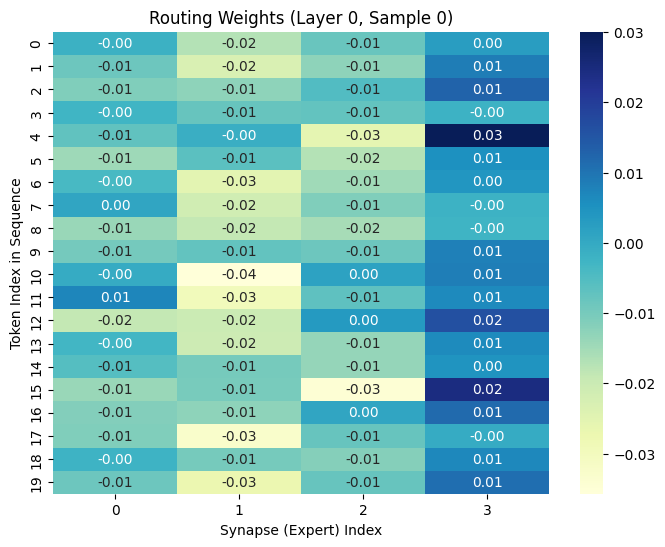

In [4]:
# Get routing weights of the first layer of the first sample
layer_idx = 0
sample_idx = 0
weights = routing_weights[layer_idx][sample_idx].cpu().numpy()

plt.figure(figsize=(8, 6))
sns.heatmap(weights, cmap="YlGnBu", annot=True, fmt=".2f")
plt.title(f"Routing Weights (Layer {layer_idx}, Sample {sample_idx})")
plt.xlabel("Synapse (Expert) Index")
plt.ylabel("Token Index in Sequence")
plt.show()